In [3]:
%run setup_matplotlib.ipynb

In [4]:
import numpy as np

QINV = 62209
KYBER_Q = 3329

def get_int16(t, lsb_idx):
    return int.from_bytes([t[lsb_idx], t[lsb_idx+1]], byteorder='little', signed=True)

def montgomery_reduce(a: int) -> int:
    a16 = np.int16(a & 0xFFFF) if a < 0 else np.int16(a % 2**16)
    t16 = np.int16(np.int32(a16) * QINV)
    u = np.int32(a) - np.int32(t16) * KYBER_Q
    return int(u >> 16)

def mr_vec(a):
    a32 = np.asarray(a, dtype=np.int32)

    t16 = (
        a32.astype(np.int16)
           .astype(np.int32) * QINV
    ).astype(np.int16).astype(np.int32)

    u = a32 - t16 * KYBER_Q
    return (u >> 16).astype(np.int64)


def smlad(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo + np.int32(a_hi) * b_hi)

def HW_int32(x: np.int32) -> int:
    x = np.int32(x)
    u = x.view(np.uint32)
    return int(u).bit_count()



import warnings
warnings.filterwarnings('ignore')


100%|██████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 3590.56it/s]


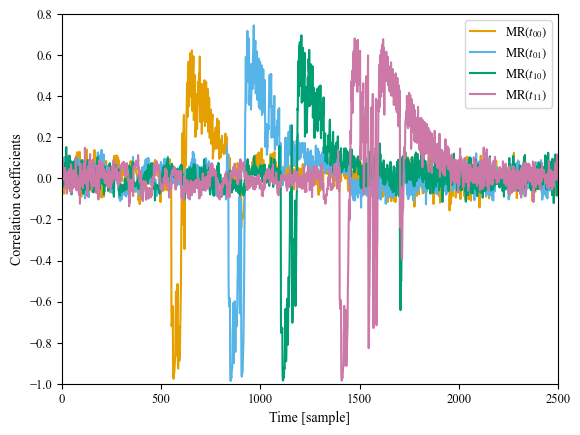

In [8]:
### Check correlations
from scaueclib import OnlineCPA
from tqdm import tqdm
#import matplotlib.pyplot as plt

dim = 5000

onlineVec_acc_0 = OnlineCPA(dim)
onlineVec_acc_1 = OnlineCPA(dim)
onlineVec_acc_2 = OnlineCPA(dim)
onlineVec_acc_3 = OnlineCPA(dim)

isMR = False

N = 500
for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
    
    zeta = np.int16(-1044) 
    u_zeta = montgomery_reduce(np.int32(zeta) * u1)
    
    acc_0 = smlad(s0_0, r0, u0, r1) + smlad(s1_0, r2, u_zeta, r3)
    acc_1 = smlad(s0_1, -r0, u0, r1) + smlad(s1_1, -r2, u_zeta, r3)
        
    acc_2 = smlad(s0_0, r4, u1, r5) + smlad(s1_0, r6, u0, r7)
    acc_3 = smlad(s0_1, -r4, u1, r5) + smlad(s1_1, -r6, u0, r7)

    onlineVec_acc_0.update(trace, HW_int32(montgomery_reduce(acc_0)))
    onlineVec_acc_1.update(trace, HW_int32(montgomery_reduce(acc_1)))
    onlineVec_acc_2.update(trace, HW_int32(montgomery_reduce(acc_2)))
    onlineVec_acc_3.update(trace, HW_int32(montgomery_reduce(acc_3)))

pearson_corr_acc0 = onlineVec_acc_0.get_pearson_corr()
pearson_corr_acc1 = onlineVec_acc_1.get_pearson_corr()
pearson_corr_acc2 = onlineVec_acc_2.get_pearson_corr()
pearson_corr_acc3 = onlineVec_acc_3.get_pearson_corr()

plt.plot(pearson_corr_acc0, label=r"$\text{MR}(t_{00})$")
plt.plot(pearson_corr_acc1, label=r"$\text{MR}(t_{01})$")
plt.plot(pearson_corr_acc2, label=r"$\text{MR}(t_{10})$")
plt.plot(pearson_corr_acc3, label=r"$\text{MR}(t_{11})$")

plt.legend()

plt.xlim(0, 2500)
plt.ylim(-1.0, 0.8)
plt.ylabel("Correlation coefficients")
plt.xlabel("Time [sample]")

plt.show()

idx_acc0_argmin = np.argmin(pearson_corr_acc0)
idx_acc1_argmin = np.argmin(pearson_corr_acc1)
idx_acc2_argmin = np.argmin(pearson_corr_acc2)
idx_acc3_argmin = np.argmin(pearson_corr_acc3)


In [9]:
print(f"Argmin of t00 : {idx_acc0_argmin}")
print(f"Argmin of t01 : {idx_acc1_argmin}")
print(f"Argmin of t10 : {idx_acc2_argmin}")
print(f"Argmin of t11 : {idx_acc3_argmin}")


Argmin of t00 : 563
Argmin of t01 : 851
Argmin of t10 : 1115
Argmin of t11 : 1411


In [26]:
from tqdm import tqdm
import numpy as np

N = 1000
dim = 2500

argmin_t10 = 1115
argmin_t11 = 1411

u0_vec = np.zeros(N)
u1_vec = np.zeros(N)

L0 = np.zeros(N)
L1 = np.zeros(N)

for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    #r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]

    L0[i] = trace[argmin_t10]
    L1[i] = trace[argmin_t11]

    u0_vec[i] = u0
    u1_vec[i] = u1

    assert((s0_0 + s0_1) % KYBER_Q == 2732)
    assert((s1_0 + s1_1) % KYBER_Q == 2607)

print("s0 =", (s0_0 + s0_1) % KYBER_Q)
print("s1 =", (s1_0 + s1_1) % KYBER_Q)

s0_true = (s0_0 + s0_1) % KYBER_Q
s1_true = (s1_0 + s1_1) % KYBER_Q

100%|████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3232.98it/s]

s0 = 2732
s1 = 2607


In [27]:
#print(np.mean(L0), np.mean(L1))
C = (L0 - np.mean(L0)) * (L1 - np.mean(L1))
#print(C)

In [8]:
_b = np.arange(1 << 16, dtype=np.uint16).view(np.uint8).reshape(-1, 2)
HW16 = np.unpackbits(_b, axis=1).sum(axis=1).astype(np.uint8)

def hw_u16(x):
    return HW16[(x.astype(np.int64) & 0xFFFF).astype(np.uint16)].astype(np.float32)

def hw_i32(x):
    x = x.astype(np.int64) & 0xFFFFFFFF
    return HW16[(x & 0xFFFF).astype(np.uint16)].astype(np.float32) + \
           HW16[((x>>16)&0xFFFF).astype(np.uint16)].astype(np.float32)

def to_signed(x, q):
    x = x % q
    return np.where(x > q//2, x - q, x) 

def build_opt_function(q):
    h = hw_u16(to_signed(np.arange(q), q)).astype(np.float64) 
    #h = hw_u16(np.arange(q)).astype(np.float64)
    #h = hw_i32(np.arange(q*q)).astype(np.float64)
    g = h - h.mean()
    G = np.fft.fft(g)
    f = np.fft.ifft(G * G).real / q
    f -= f.mean(); f /= (f.std() + 1e-12)
    f = f.astype(np.float32)

    return f

In [20]:
f_opt = build_opt_function(KYBER_Q)

corrs = [0] * (KYBER_Q)

s0 = s0_true
for s1 in tqdm(range(1, KYBER_Q)):
    X = f_opt[mr_vec(s0 * u1_vec + s1 * u0_vec)]
    corr = np.corrcoef(X, C)[0][1]

    corrs[s1] = corr

100%|███████████████████████████████████████████████████████████████| 3328/3328 [00:00<00:00, 31484.19it/s]


Max s1 2607 0.5259332656798774
True s1 2607 0.5259332656798774


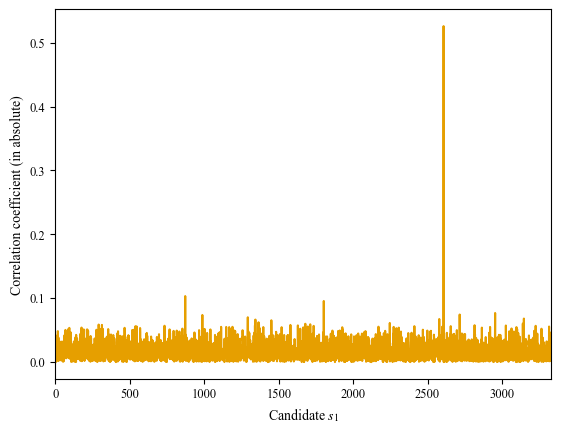

In [21]:
idx_max = np.argmax(np.abs(corrs))
print("Max s1", idx_max, corrs[idx_max])
print("True s1", s1_true, corrs[s1_true])
#print(np.abs(corrs)[2673])

plt.plot(np.abs(corrs))
plt.xlim(0, KYBER_Q)

plt.ylabel("Correlation coefficient (in absolute)")
plt.xlabel(r"Candidate $s_1$")

plt.show()


Max s1 2607 0.5379909526446522
True s1 2607 0.5379909526446522


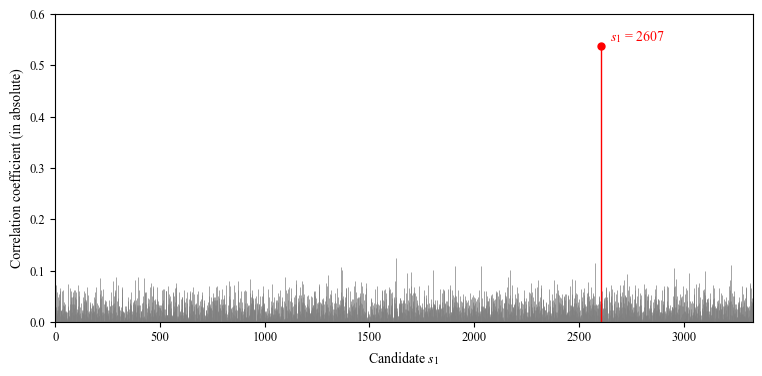

In [8]:
idx_max = int(np.argmax(np.abs(corrs)))
print("Max s1", idx_max, corrs[idx_max])
print("True s1", s1_true, corrs[s1_true])

ac = np.abs(corrs)
fig, ax = plt.subplots(figsize=(9, 4))
ax.vlines(range(KYBER_Q), 0, ac, color="gray", lw=0.5)        # 細いスパイク
ax.vlines(idx_max, 0, ac[idx_max], color="red", lw=1.0)       # ピークだけ赤
ax.scatter(idx_max, ac[idx_max], color="red", s=25, zorder=5)
ax.annotate(rf"$s_1$ = {idx_max}", (idx_max, ac[idx_max]),
            textcoords="offset points", xytext=(6, 4), color="red")
ax.set_xlim(0, KYBER_Q); ax.set_ylim(0, 0.60)

ax.set_xlabel(r"Candidate $s_1$"); ax.set_ylabel("Correlation coefficient (in absolute)")

plt.savefig("images/corrs_s1_against_true_s0.pdf", bbox_inches="tight")

plt.show()

In [9]:
!pdfcrop images/corrs_s1_against_true_s0.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/corrs_s1_against_true_s0-crop.pdf'.


In [43]:
## Fast ver
f_opt = build_opt_function(KYBER_Q)

q = KYBER_Q
scores = np.zeros((q, q), dtype=np.float32)
B = (np.arange(q, dtype=np.int64)[:, None] * u0_vec[None, :])
Cc = C.astype(np.float32)
Cden = float(np.sqrt((Cc * Cc).sum())) or 1.0

for s0 in tqdm(range(q)):
    X = mr_vec(s0 * u1_vec[None, :] + B)
    P = f_opt[X]                        
    num = P @ Cc
    den = np.sqrt((P * P).sum(axis=1))
    scores[s0, :] = np.abs(num) / (den * Cden + 1e-12)


100%|██████████████████████████████████████████████████████████████████| 3329/3329 [00:50<00:00, 65.64it/s]


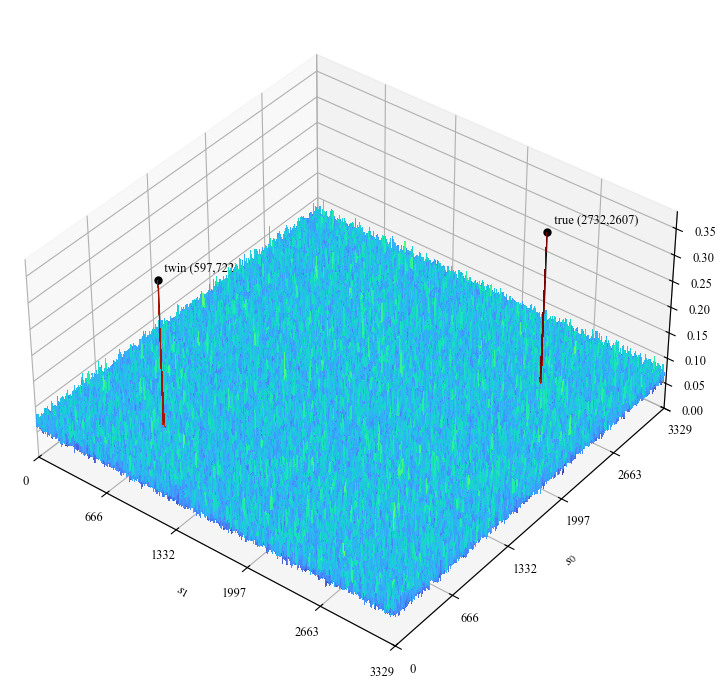

In [47]:
import numpy as np
import matplotlib.pyplot as plt

#Z = np.abs(np.nan_to_num(np.load('all_corrcoef_s0_s1.npy')))
Z = np.abs(np.nan_to_num(scores))
q = Z.shape[0]
pk = np.unravel_index(np.argmax(Z), Z.shape)          # (s0, s1)
tw = ((q - pk[0]) % q, (q - pk[1]) % q)               # 符号ツイン (-s0,-s1)

# ピークを残して縮小（max プーリング）
def maxpool(Z, k):
    m = (Z.shape[0] // k) * k
    return Z[:m, :m].reshape(m//k, k, m//k, k).max(axis=(1, 3))

k = max(1, q // 420)
Zs = maxpool(Z, k); qs = Zs.shape[0]
X, Y = np.meshgrid(np.arange(qs)*k, np.arange(qs)*k)   # 実座標 0..q でメッシュ

fig = plt.figure(figsize=(10, 7)) 
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(X, Y, Zs, cmap="turbo", rcount=qs, ccount=qs, linewidth=0, antialiased=False)

# 真値と符号ツインの両方に 縦線+点+注釈
for p, c, lbl in [(pk, "k", "true"), (tw, "k", "twin")]:
    ps = (p[0] // k, p[1] // k)                        # 縮小配列上のインデックス（高さ取得用）
    ax.plot([p[1], p[1]], [p[0], p[0]], [0, Zs[ps]], color=c, lw=1)   # 位置は実座標 p
    ax.scatter([p[1]], [p[0]], [Zs[ps]], color=c, s=25)
    ax.text(p[1], p[0], Zs[ps]*1.05, f"  {lbl} ({p[0]},{p[1]})", fontsize=9, color=c)

ax.set_xlabel(r"$s_1$")
ax.set_ylabel(r"$s_0$")
#ax.set_zlabel("Correlation coefficient")
ax.set_xlim(0, q); ax.set_ylim(0, q)                  # 軸範囲を 0..q に固定
ax.set_xticks(np.linspace(0, q, 6).round().astype(int))
ax.set_yticks(np.linspace(0, q, 6).round().astype(int))
ax.set_zlim(0, Zs.max()*1.1)

ax.view_init(elev=38, azim=-52)
ax.set_box_aspect((1, 1, 0.55))
#fig.colorbar(surf, shrink=0.55, pad=0.1, label="|corr|")
plt.tight_layout()

#plt.savefig("images/HOCPA_all_s0_s1.pdf", bbox_inches="tight")

plt.show()

In [32]:
f_opt = build_opt_function(KYBER_Q)

all_corrs = np.zeros((KYBER_Q, KYBER_Q))
for s0 in tqdm(range(1, KYBER_Q)):
    for s1 in range(1, KYBER_Q):
        X = f_opt[ mr_vec(s0 * u1_vec + s1 * u0_vec) ]
        corr = np.corrcoef(X, C)[0][1]
    
        all_corrs[s0][s1] = corr

#np.save("all_corrcoef_s0_s1.npy", all_corrs)

100%|██████████████████████████████████████████████████████████████████| 3328/3328 [03:36<00:00, 15.35it/s]


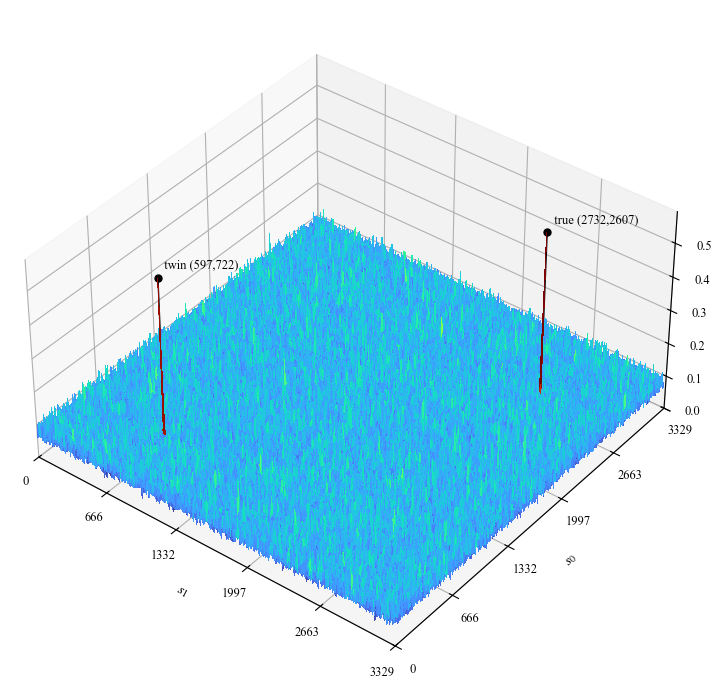

In [11]:
import numpy as np
import matplotlib.pyplot as plt

Z = np.abs(np.nan_to_num(np.load('all_corrcoef_s0_s1.npy')))
q = Z.shape[0]
pk = np.unravel_index(np.argmax(Z), Z.shape)          # (s0, s1)
tw = ((q - pk[0]) % q, (q - pk[1]) % q)               # 符号ツイン (-s0,-s1)

# ピークを残して縮小（max プーリング）
def maxpool(Z, k):
    m = (Z.shape[0] // k) * k
    return Z[:m, :m].reshape(m//k, k, m//k, k).max(axis=(1, 3))

k = max(1, q // 420)
Zs = maxpool(Z, k); qs = Zs.shape[0]
X, Y = np.meshgrid(np.arange(qs)*k, np.arange(qs)*k)   # 実座標 0..q でメッシュ

fig = plt.figure(figsize=(10, 7)) 
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(X, Y, Zs, cmap="turbo", rcount=qs, ccount=qs,
                       linewidth=0, antialiased=False)

# 真値と符号ツインの両方に 縦線+点+注釈
for p, c, lbl in [(pk, "k", "true"), (tw, "k", "twin")]:
    ps = (p[0] // k, p[1] // k)                        # 縮小配列上のインデックス（高さ取得用）
    ax.plot([p[1], p[1]], [p[0], p[0]], [0, Zs[ps]], color=c, lw=1)   # 位置は実座標 p
    ax.scatter([p[1]], [p[0]], [Zs[ps]], color=c, s=25)
    ax.text(p[1], p[0], Zs[ps]*1.05, f"  {lbl} ({p[0]},{p[1]})", fontsize=9, color=c)

ax.set_xlabel(r"$s_1$")
ax.set_ylabel(r"$s_0$")
#ax.set_zlabel("Correlation coefficient")
ax.set_xlim(0, q); ax.set_ylim(0, q)                  # 軸範囲を 0..q に固定
ax.set_xticks(np.linspace(0, q, 6).round().astype(int))
ax.set_yticks(np.linspace(0, q, 6).round().astype(int))
ax.set_zlim(0, Zs.max()*1.1)

ax.view_init(elev=38, azim=-52)
ax.set_box_aspect((1, 1, 0.55))
#fig.colorbar(surf, shrink=0.55, pad=0.1, label="|corr|")
plt.tight_layout()

plt.savefig("images/HOCPA_all_s0_s1.pdf", bbox_inches="tight")

plt.show()

In [17]:
!gs -sDEVICE=pdfwrite -dCompatibilityLevel=1.4 -dPDFSETTINGS=/screen -dNOPAUSE -dQUIET -dBATCH -sOutputFile=images/HOCPA_all_s0_s1_comporessed.pdf images/HOCPA_all_s0_s1.pdf
!pdfcrop images/HOCPA_all_s0_s1_comporessed.pdf;

In [7]:
from tqdm import tqdm
import numpy as np

N = 1000
dim = 2500
zeta = np.int16(-1044)

argmin_t00 = 563
argmin_t01 = 851

u0_vec = np.zeros(N)
u1_vec = np.zeros(N)

L0 = np.zeros(N)
L1 = np.zeros(N)

for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul_v2/sample_{i:08}.npz")
    trace = sample["trace"][:dim]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, u0, u1 = vals[:6]
    #r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]

    L0[i] = trace[argmin_t00]
    L1[i] = trace[argmin_t01]

    u0_vec[i] = u0
    u1_vec[i] = u1

    assert((s0_0 + s0_1) % KYBER_Q == 2732)
    assert((s1_0 + s1_1) % KYBER_Q == 2607)

print("s0 =", (s0_0 + s0_1) % KYBER_Q)
print("s1 =", (s1_0 + s1_1) % KYBER_Q)

s0_true = (s0_0 + s0_1) % KYBER_Q
s1_true = (s1_0 + s1_1) % KYBER_Q


#print(np.mean(L0), np.mean(L1))
C = (L0 - np.mean(L0)) * (L1 - np.mean(L1))
#print(C)

100%|████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3404.73it/s]

s0 = 2732
s1 = 2607


In [22]:
f_opt = build_opt_function(KYBER_Q)

corrs = [0] * (KYBER_Q)

s0 = s0_true % KYBER_Q
for s1 in tqdm(range(1, KYBER_Q)):
    t = mr_vec(u1_vec * zeta)
    X = f_opt[mr_vec(s0 * u0_vec + s1 * t)]
    corr = np.corrcoef(X, C)[0][1]

    corrs[s1] = corr

100%|███████████████████████████████████████████████████████████████| 3328/3328 [00:00<00:00, 29537.23it/s]


Max s1 2607 0.5160030527376324
True s1 2607 0.5160030527376324


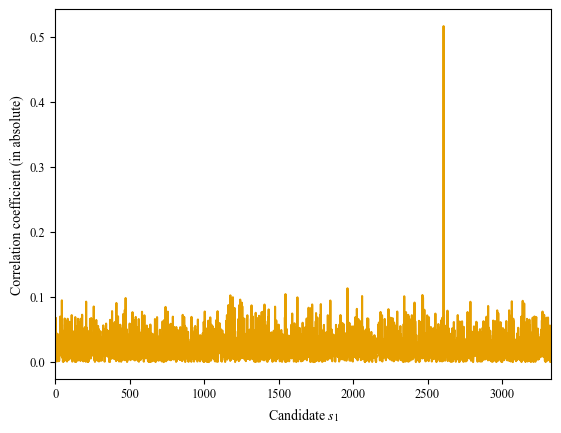

In [23]:
idx_max = np.argmax(np.abs(corrs))
print("Max s1", idx_max, corrs[idx_max])
print("True s1", s1_true, corrs[s1_true])
#print(np.abs(corrs)[2673])

plt.plot(np.abs(corrs))
plt.xlim(0, KYBER_Q)

plt.ylabel("Correlation coefficient (in absolute)")
plt.xlabel(r"Candidate $s_1$")

plt.show()
